In [39]:
import copy, math, os, pickle, time, pandas as pd, numpy as np, scipy.stats as ss, pathlib as pl, gc, pyarrow, tracemalloc

from pathlib import Path

from dotenv import load_dotenv

from matplotlib import pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score, roc_auc_score, accuracy_score, f1_score, confusion_matrix
from sklearn.calibration import CalibrationDisplay


In [40]:


#GAP_TIME          = 6  # In hours.  I don't need this as there is already a gap between end of data and predicted outcome (at 7 days)
WINDOW_SIZE       = 49 # In hours.  For my project, this is 49 hours as I have 24 hours prior to ICU inttime, 24 hours in ICU.  
SEED              = 1
ID_COLS           = ['subject_id', 'hadm_id', 'icustay_id']
ID_COLS_HOURLY = ID_COLS + ['hours_in']
TESTING = False          # set False for the full cohort run
PROJECT_ROOT = Path.cwd().parents[0]   # adjust after checking Path.cwd()
load_dotenv()
BACKUP_ROOT = Path(os.environ["BACKUP_ROOT"])
FLAT_DATA_PATH = BACKUP_ROOT / 'results' / 'models' / 'flat_data.pkl'  # location to save the processed data (train/dev/test) for later model evaluation
PLOTS_DIR = PROJECT_ROOT / 'results'/ 'plots'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'
train_frac, dev_frac, test_frac = 0.7, 0.1, 0.2 

np.random.seed(SEED)
#torch.manual_seed(SEED)

In [41]:
class DictDist():
    def __init__(self, dict_of_rvs): self.dict_of_rvs = dict_of_rvs
    def rvs(self, n):
        a = {k: v.rvs(n) for k, v in self.dict_of_rvs.items()}
        out = []
        for i in range(n): out.append({k: vs[i] for k, vs in a.items()})
        return out
    
class Choice():
    def __init__(self, options): self.options = options
    def rvs(self, n): return [self.options[i] for i in ss.randint(0, len(self.options)).rvs(n)]

In [42]:
import getpass
from sqlalchemy import create_engine

pg_user = 'postgres'      # same value you use to connect via psql
pg_host = 'localhost'          # or wherever your Postgres server is
pg_port = 5432
pg_dbname = 'mimiciv'

pg_password = getpass.getpass('Postgres password: ')

engine = create_engine(
    f'postgresql+psycopg2://{pg_user}:{pg_password}@{pg_host}:{pg_port}/{pg_dbname}'
)

The following cells create the datasets - these are saved as pickle files and can be picked up just before sklearn section

In [ ]:
%%time

# Read in hourly dataset


hourly_table = 'msc_project.sample_hourly_data' if TESTING else 'msc_project.hourly_data'

hourly_query = f"SELECT * FROM {hourly_table}"

data_full_lvl2 = (
    pd.read_sql(hourly_query, engine)
    .set_index(ID_COLS_HOURLY)
    .drop(columns='hour_end')   # dropping hour_end as it is redundant - hours_in tracks time since admission.
    .astype('float32')              # data type should be float (dealing with potential for all missing values). 
                                    # can specify float32 rather than default float64 to reduce memory usage.
)

print(data_full_lvl2.shape)

In [ ]:
%%time
# read in static data

statics_table = 'msc_project.sample_allpatients' if TESTING else 'msc_project.allpatients'

statics_query = f"SELECT * FROM {statics_table}"

statics = pd.read_sql(statics_query, engine).set_index(ID_COLS)

print(statics.shape)

(51838, 12)
CPU times: total: 1.14 s
Wall time: 4.96 s


In [ ]:
%%time

# read in the alternative representation data

alt_table = 'msc_project.sample_alternative_data' if TESTING else 'msc_project.alternative_data'

alt_query = f"SELECT * FROM {alt_table}"

data_full_alt = pd.read_sql(alt_query, engine)

print(data_full_alt.shape)

(1316988, 14)
CPU times: total: 39.8 s
Wall time: 6min 1s


In [ ]:
""""
Adapted from the MIMIC-Extract function 'simple_imputer' in mimic3benchmark.preprocessing.utils, which
deals with missing values in the hourly data. The original function takes a dataframe with a multi-index of 
(subject_id, hadm_id, icustay_id, hours_in) and columns with a multi-index of (label, LEVEL1, LEVEL2, 
Aggregation Function). The function fills in missing values for the 'mean' aggregation function using 
forward fill and the mean of the icustay, and creates a 'mask' column indicating whether the original value 
was present or not. It also calculates the time since the last measurement for each variable.

This adaptation takes a dataframe with only one column per variable for the mean per hour. This is indexed by 
the ID columns and hour. If there is no measurement in a given hour, it is supplied as NaN in the input. 

I have made a decision to forward fill the missing values, but not to fill missing values at the start with the 
mean for the stay. It seems incorrect to impute values for hours before the first measurement - I do not want to use measures from 
after the relevant time point to impute values for before the first measurement. Instead I am filling with the mean from the training
data standardization (zero) (this function will be run after standardization).

"""

def simple_imputer(df, id_cols=ID_COLS):

    df = df.copy()
    # NB the forward fill depends on hours_in being in order for each stay.
    df = df.sort_index()    # Therefore sort. The index has been set earlier to be the ID_COLS + ['hours_in'] for the hourly data.

    mask = df.notna().astype(float)    # see later for why we convert to float. This is the mask of whether a 
                                        # measurement was present or not.
    imputed = (
        df.groupby(level=id_cols).ffill()              # forward fills from the last measurement.
        .fillna(0)                                      # otherwise, fills with zero (mean from training dataset, not the mean value for the stay)
    )

    # grouping by stay here, this will mean that the last observed time should be only within the stay, 
    # not across other stays as in the original notebook. 
    is_absent = 1 - mask                # This is now 1 if the measurement is absent, 0 if there is a measurement.
    total_hours_of_absence = is_absent.groupby(level=id_cols).cumsum()   # cumulative sum of hours with no measurement for the stay.
    absent_hours_before_last_measure = (
        total_hours_of_absence[is_absent == 0]
        .groupby(level=id_cols).ffill()   
    )   # This is the number of absent hours before the latest measurement. 
    hours_since_last_measure = (total_hours_of_absence - absent_hours_before_last_measure).fillna(100)  # 100 is beyond the max hours covered in my data.

    df_out = pd.concat(
        [imputed, mask, hours_since_last_measure],             # temporary - include all of the measures to review progress. 
        axis = 1,
        keys = ['mean', 'mask', 'hours_since_last_measure']     # rename imputed as mean to match the Wang pipeline code.
    )

    # Carrying out renaming and restructuring here to work with later code from the Wang pipeline.
    df_out.columns.names = ['Aggregation Function', 'variable']     # need top level names
    df_out = df_out.swaplevel(0, 1, axis=1)                           # swap levels so variable is top level, aggregation next, to match Wang pipeline.
    df_out.sort_index(axis=1, inplace=True)                             # sort index to be consistent with the Wang pipeline.

    return df_out

In [ ]:
""""
Adapted from the MIMIC-Extract cell in the notebook 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
in mimic3benchmark.preprocessing.utils, which splits the data into train, dev and test sets and also deals 
with standardisation.   
Updates compared to the original code:
- Removed the raw dataset as I am not using it.
- limited to a single outcome, length of stay after 7 days from ICU admission.
- No truncation based on the number of hours in the ICU, as this has already been done in my SQL processing.
- No use of GAP_TIME to ensure a gap between the end of the data and the predicted outcome, as there is already a gap between the last 
time point at 24 hours post-ICU admission and the predicted outcome at 7 days post ICU admission.
- Splitting the different stages into separate cells for clarity.

-- First - restrict to stays that are in Ys i.e. have a label
"""


Ys = statics[['los_icu']].copy()  # No need to filter for max_hours > WINDOW_SIZE + GAP_TIME as this check is done in the SQL query for the hourly data. GAP_TIME is not needed as there is already a gap between the end of the data and the predicted outcome (at 7 days). 
Ys['los_7'] = (Ys['los_icu'] > 7).astype(float) # Amending to convert to float - original line didn't modify Ys.
Ys.drop(columns=['los_icu'], inplace=True)  

# Restrict to stays that are in Ys i.e. have a label
data_full_lvl2 = data_full_lvl2[
    data_full_lvl2.index.get_level_values('icustay_id').isin(
        set(Ys.index.get_level_values('icustay_id'))
    )
]

data_full_alt = data_full_alt[data_full_alt['icustay_id'].isin(
    set(Ys.index.get_level_values('icustay_id'))
)]



In [ ]:
print(data_full_lvl2.shape)
print(data_full_alt.shape)

(2540062, 30)
(1316988, 14)


No change after restricting to rows with label - number of rows is the same as before.

In [ ]:
"""
Split into train, test and dev by subject_id
"""
lvl2_subj_idx, Ys_subj_idx = [df.index.get_level_values('subject_id') for df in (data_full_lvl2, Ys)] # no raw dataset.
lvl2_subjects = set(lvl2_subj_idx)
assert lvl2_subjects == set(Ys_subj_idx), "Subject ID pools differ!"

np.random.seed(SEED)
subjects, N = np.random.permutation(list(lvl2_subjects)), len(lvl2_subjects)
N_train, N_dev, N_test = int(train_frac * N), int(dev_frac * N), int(test_frac * N)
train_subj = subjects[:N_train]
dev_subj   = subjects[N_train:N_train + N_dev]
test_subj  = subjects[N_train+N_dev:]

[(lvl2_train, lvl2_dev, lvl2_test), (Ys_train, Ys_dev, Ys_test)] = [     # again no raw dataset.
    [df[df.index.get_level_values('subject_id').isin(s)] for s in (train_subj, dev_subj, test_subj)] \
    for df in (data_full_lvl2, Ys)
]

alt_train, alt_dev, alt_test = [
    data_full_alt[data_full_alt['subject_id'].isin(s)] for s in (train_subj, dev_subj, test_subj)
    ]


In [ ]:
print(train_subj.shape)
print(dev_subj.shape)
print(test_subj.shape)

(36286,)
(5183,)
(10369,)


In [ ]:

"""
# Now standardize the hourly dataset before calling simple_imputer()
"""
lvl2_means = lvl2_train.mean(axis=0)
lvl2_stds = lvl2_train.std(axis=0)
lvl2_stds = lvl2_stds.replace(0,1)  # If std is zero, can replace with 1 to avoid division by zero in the below standardisation step.

lvl2_train = (lvl2_train - lvl2_means) / lvl2_stds
lvl2_dev = (lvl2_dev - lvl2_means) / lvl2_stds
lvl2_test = (lvl2_test - lvl2_means) / lvl2_stds

In [ ]:
"""
# Deal with missing values - hourly representation
"""
# Now impute  # Call simple_imputer() to get the structure expected in the pipeline
lvl2_train, lvl2_dev, lvl2_test = [
    simple_imputer(df) for df in (lvl2_train, lvl2_dev, lvl2_test)
]

# delete the non-imputed versions to save space here??

# Standardize for hours since last measure, which has been added to the hourly representation, to avoid problems with scale:
idx = pd.IndexSlice  # add to config at start?
hslm_means, hslm_stds = lvl2_train.loc[:, idx[:, 'hours_since_last_measure']].mean(axis=0), lvl2_train.loc[:, idx[:, 'hours_since_last_measure']].std(axis=0),
hslm_stds = hslm_stds.replace(0, 1)

lvl2_train.loc[:, idx[:, 'hours_since_last_measure']] = (lvl2_train.loc[:, idx[:, 'hours_since_last_measure']] - hslm_means)/hslm_stds
lvl2_dev.loc[:, idx[:,'hours_since_last_measure']] = (lvl2_dev.loc[:, idx[:,'hours_since_last_measure']] - hslm_means)/hslm_stds
lvl2_test.loc[:, idx[:,'hours_since_last_measure']] = (lvl2_test.loc[:, idx[:,'hours_since_last_measure']] - hslm_means)/hslm_stds

In [ ]:
"""
Pivot both representations to wide
"""

# pivot the hourly representation to wide:
# raw_train, raw_dev, raw_test, lvl2_train, lvl2_dev, lvl2_test = [                 # no need to call simple_imputer() here, as it's been called earlier on the full dataset.
#     simple_imputer(df) for df in (raw_train, raw_dev, raw_test, lvl2_train, lvl2_dev, lvl2_test)
# ]
lvl2_flat_train, lvl2_flat_dev, lvl2_flat_test = [                                  # removed the raw datasets.
    df.unstack('hours_in') for df in (
        lvl2_train, lvl2_dev, lvl2_test
    )
]

# alt representation - pivot to wide
alt_flat_train, alt_flat_dev, alt_flat_test = [
    df.set_index([
        'subject_id', 'hadm_id', 'icustay_id', 'variable_name'
        ]
        ).unstack('variable_name') for df in (alt_train, alt_dev, alt_test)
]



In [ ]:
print(lvl2_train.shape)        # long format, pre-pivot - sanity check
print(lvl2_flat_train.shape)   # wide format, post-pivot
print(lvl2_flat_train.columns.duplicated().sum())

print(alt_train.shape)        # long format, pre-pivot - sanity check
print(alt_flat_train.shape)   # wide format, post-pivot
print(alt_flat_train.columns.duplicated().sum())

(1778014, 90)
(36286, 4410)
0
(921657, 14)
(36285, 300)
0


In [ ]:
# Make sure I have a row for every ICU stay for alt representation - this may not be the case if any had no obs at all

alt_flat_train = alt_flat_train.reindex(Ys_train.index)
alt_flat_dev = alt_flat_dev.reindex(Ys_dev.index)
alt_flat_test = alt_flat_test.reindex(Ys_test.index)

In [ ]:
print(alt_flat_train.shape)
print(alt_flat_dev.shape)
print(alt_flat_test.shape)

print(alt_train.shape)
print(alt_dev.shape)
print(alt_test.shape)

(36286, 300)
(5183, 300)
(10369, 300)
(921657, 14)
(131734, 14)
(263597, 14)


In [ ]:
print(lvl2_flat_train.shape)
print(lvl2_flat_dev.shape)
print(lvl2_flat_test.shape)

print(lvl2_train.shape)
print(lvl2_dev.shape)
print(lvl2_test.shape)

(36286, 4410)
(5183, 4410)
(10369, 4410)
(1778014, 90)
(253967, 90)
(508081, 90)


In [ ]:
# Deal with missing values - alt representation

# For alternative representation, missing values need decisions - cannot forwardfill and mask as for the hourly representation.

for df in (alt_flat_train, alt_flat_dev, alt_flat_test):
    n_missing = df.isnull().sum().sum()
    if n_missing:
        print(f"{n_missing} missing values")

1998758 missing values


283055 missing values
567201 missing values


In [ ]:
# Add missingness indicator for those ICU stays where a variable is never observed, based on value count being NaN
# NB this means no observations during the stay, does not involve missing values for derived variables e.g. where standard deviation is zero
# Then, I will impute with the mean from the training data
# This missingness indicator will be added after standardization

alt_missing_train, alt_missing_dev, alt_missing_test = [
    df['value_count'].isnull().astype(int)
    for df in (alt_flat_train, alt_flat_dev, alt_flat_test)
]

# need to add column level to indicate this is a new measure missing_value, for each of the concepts

for df in (alt_missing_train, alt_missing_dev, alt_missing_test):
    df.columns = pd.MultiIndex.from_product([['value_missing'], df.columns])


# alt_missing_train.head()
# These are now ready to add later

In [ ]:
# standardize alt representation  - (already done for hourly representation, prior to imputing missing data)
alt_means = alt_flat_train.mean(axis=0)
alt_stds = alt_flat_train.std(axis=0)  
alt_stds = alt_stds.replace(0, 1) # If std is zero, can replace with 1 to avoid division by zero in the below standardisation step. 

alt_flat_train = (alt_flat_train - alt_means) / alt_stds
alt_flat_dev = (alt_flat_dev - alt_means) / alt_stds
alt_flat_test = (alt_flat_test - alt_means) / alt_stds

In [ ]:
# Missing data - fill missings with 0 - after standardization this represents the training average

alt_flat_train = alt_flat_train.fillna(0)
alt_flat_dev = alt_flat_dev.fillna(0)
alt_flat_test = alt_flat_test.fillna(0)

# Now add the missingness indicator variable previously generated

alt_flat_train = pd.concat([alt_flat_train, alt_missing_train], axis=1)
alt_flat_dev = pd.concat([alt_flat_dev, alt_missing_dev], axis=1)
alt_flat_test = pd.concat([alt_flat_test, alt_missing_test], axis=1)

In [ ]:
for df in lvl2_flat_train, lvl2_flat_dev, lvl2_flat_test: assert not df.isnull().any().any()       # check for missings. removed the raw datasets.
for df in alt_flat_train, alt_flat_dev, alt_flat_test: assert not df.isnull().any().any()

In [ ]:
print(alt_flat_train.shape)
print(alt_flat_dev.shape)
print(alt_flat_test.shape)


(36286, 330)
(5183, 330)
(10369, 330)


In [ ]:
# save the processed flat data for modelling to save having to recreate these. 

lvl2_flat_train.to_parquet(
    BACKUP_ROOT / "results" / "data" / "lvl2_flat_train.parquet", engine = "pyarrow"
)
lvl2_flat_dev.to_parquet(
    BACKUP_ROOT / "results" / "data" / "lvl2_flat_dev.parquet", engine = "pyarrow"
)
lvl2_flat_test.to_parquet(
    BACKUP_ROOT / "results" / "data" / "lvl2_flat_test.parquet", engine = "pyarrow"
)
alt_flat_train.to_parquet(
    BACKUP_ROOT / "results" / "data" / "alt_flat_train.parquet", engine = "pyarrow"
)
alt_flat_dev.to_parquet(
    BACKUP_ROOT / "results" / "data" / "alt_flat_dev.parquet", engine = "pyarrow"
)
alt_flat_test.to_parquet(
    BACKUP_ROOT / "results" / "data" / "alt_flat_test.parquet", engine = "pyarrow"
)
Ys_train.to_parquet(
    BACKUP_ROOT / "results" / "data" / "Ys_train.parquet", engine = "pyarrow"
)
Ys_dev.to_parquet(
    BACKUP_ROOT / "results" / "data" / "Ys_dev.parquet", engine = "pyarrow"
)
Ys_test.to_parquet(
    BACKUP_ROOT / "results" / "data" / "Ys_test.parquet", engine = "pyarrow"
)

Task prediction

Hyperparameters

In [ ]:
""""
Adapted from the MIMIC-Extract cell in the notebook 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
in mimic3benchmark.preprocessing.utils, which sets up hyperparameter distributions for logistic regression, random forest and GRU models.
To start with, I will set up only logistic regression and random forest models. I will begin using the same hyperparameters before 
considering adjustments.
2026-08-14 replaced penalty (deprecated) with l1_ratio.
"""

N = 30

LR_dist = DictDist({
    'C': Choice(np.geomspace(1e-3, 1e2, 10000)),  # I've reduced the range of options here, was (1e-3, 1e3, 10000)
    'l1_ratio': Choice([0, 1]),
    #'penalty': Choice(['l1', 'l2', 'elasticnet']),  # penalty is now deprecated
    'solver': Choice(['liblinear']),     # Now settled on liblinear only as problems with convergence using lbgfs and saga 
    'max_iter': Choice([100, 300, 500])  # switched from 500 as the larger max iterations to 300.
})
np.random.seed(SEED)
LR_hyperparams_list = LR_dist.rvs(N)
# for i in range(N):                              # lbfgs does not support L1 so setting L1_ratio to 0 for L2
#     if LR_hyperparams_list[i]['solver'] == 'lbfgs': 
#         LR_hyperparams_list[i]['l1_ratio'] = 0

RF_dist = DictDist({
    'n_estimators': ss.randint(50, 1000),  # 28th - increasing number estimators from (50,500) to (50,1000) to see if this also increases performance
    'max_depth': ss.randint(2, 100),    # increasing range of tree depth from (2,10) to (2,100) as the models have performed best when this is highest
    'min_samples_split': ss.randint(2, 75),
    'min_samples_leaf': ss.randint(1, 50),
})
np.random.seed(SEED)
RF_hyperparams_list = RF_dist.rvs(N)


Functions

In [ ]:
# Testing some logistic regression parameters for clarity on what is not working

# test_M = LogisticRegression(l1_ratio=1, solver='liblinear', C=1.0, max_iter=100)
# test_M.fit(lvl2_flat_train, Ys_train['los_7'])

#test_M = LogisticRegression(l1_ratio = 0.5, solver='saga', C=1.0, max_iter=100)
#test_M.fit(lvl2_flat_train, Ys_train['los_7'])  # did not converge
#test_M.fit(alt_flat_train, Ys_train['los_7'])   # did not converge

#test_M = LogisticRegression(l1_ratio = 0.5, solver='saga', C=0.1, max_iter=300)
#test_M.fit(lvl2_flat_train, Ys_train['los_7'])   # did not converge
#test_M.fit(alt_flat_train, Ys_train['los_7'])    # did not converge


In [ ]:
'''
These functions are from a MIMIC-Extract cell in the notebook 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
I have created an additional function select_hyperparameters() that does not move on to runnig the model on the test data
This will be used for initial exploration and decision making on hyperparameters to be sure of avoiding leakage.
Average precision score is used instead of roc_auc to choose hyperparameters.

'''

def select_hyperparameters(model, hyperparams_list, X_flat_train, X_flat_dev, target):
    '''
    This function is an addition to use to determine hyperparameters, which only runs the models 
    on the Dev dataset, not Test.
    Average precision score is used instead of roc_auc to choose hyperparameters.
    This is a better measure for the outcome which has a significant class imbalance.
    '''
    best_s, best_hyperparams = -np.inf, None
    for i, hyperparams in enumerate(hyperparams_list):
        print("On sample %d / %d (hyperparams = %s)" % (i+1, len(hyperparams_list), repr((hyperparams))))
        M = model(**hyperparams, random_state=SEED)
        M.fit(X_flat_train, Ys_train[target])
        s = average_precision_score(Ys_dev[target], M.predict_proba(X_flat_dev)[:, 1])
        if s > best_s:
            best_s, best_hyperparams, best_M = s, hyperparams, M
            print("New Best Score: %.2f @ hyperparams = %s" % (100*best_s, repr((best_hyperparams))))
    y_true  = Ys_dev[target]
    y_score = best_M.predict_proba(X_flat_dev)[:, 1]
    y_pred  = best_M.predict(X_flat_dev)

    auc   = roc_auc_score(y_true, y_score)
    auprc = average_precision_score(y_true, y_score)
    acc   = accuracy_score(y_true, y_pred)
    F1    = f1_score(y_true, y_pred)
    return best_M, best_hyperparams, auc, auprc, acc, F1

def run_basic(model, hyperparams_list, X_flat_train, X_flat_dev, X_flat_test, target):
    '''
    This may be run, with adjustments, after initial decision making on hyperparameters
    '''
    best_s, best_hyperparams = -np.inf, None
    for i, hyperparams in enumerate(hyperparams_list):
        print("On sample %d / %d (hyperparams = %s)" % (i+1, len(hyperparams_list), repr((hyperparams))))
        M = model(**hyperparams, random_state=SEED)
        M.fit(X_flat_train, Ys_train[target])
        s = roc_auc_score(Ys_dev[target], M.predict_proba(X_flat_dev)[:, 1])
        if s > best_s:
            best_s, best_hyperparams = s, hyperparams
            print("New Best Score: %.2f @ hyperparams = %s" % (100*best_s, repr((best_hyperparams))))

    return run_only_final(model, best_hyperparams, X_flat_train, X_flat_dev, X_flat_test, target)

def run_only_final(model, best_hyperparams, X_flat_train, X_flat_dev, X_flat_test, target):
    '''
    this may be run, with adjustments, after initial decision making on hyperparameters
    '''
    best_M = model(**best_hyperparams, random_state=SEED)
    best_M.fit(pd.concat((X_flat_train, X_flat_dev)), pd.concat((Ys_train, Ys_dev))[target])
    y_true  = Ys_test[target]
    y_score = best_M.predict_proba(X_flat_test)[:, 1]
    y_pred  = best_M.predict(X_flat_test)

    auc   = roc_auc_score(y_true, y_score)
    auprc = average_precision_score(y_true, y_score)
    acc   = accuracy_score(y_true, y_pred)
    F1    = f1_score(y_true, y_pred)
    
    return best_M, best_hyperparams, auc, auprc, acc, F1

Sklearn

In [ ]:
""""
Adapted cell from 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
Added exception handling for the case where the results file does not exist yet.
"""

RESULTS_PATH = PROJECT_ROOT / 'results' / 'models' / 'extraction_baselines-sklearn.pkl'

try:
    with open(RESULTS_PATH, mode='rb') as f: 
        results = pickle.load(f)
except FileNotFoundError:
    results = {}

RERUN = True

In [ ]:

# open the prepared datasets as needed:

# lvl2_flat_train = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "lvl2_flat_train.parquet", engine="pyarrow")
# lvl2_flat_dev = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "lvl2_flat_dev.parquet", engine="pyarrow")
# #lvl2_flat_test = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "lvl2_flat_test.parquet", engine="pyarrow")

# alt_flat_train = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "alt_flat_train.parquet", engine="pyarrow")
# alt_flat_dev = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "alt_flat_dev.parquet", engine="pyarrow")
# #alt_flat_test = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "alt_flat_test.parquet", engine="pyarrow")

# Ys_train = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "Ys_train.parquet", engine="pyarrow")
# Ys_dev = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "Ys_dev.parquet", engine="pyarrow")
# #Ys_test = pd.read_parquet(BACKUP_ROOT / "results" / "data" / "Ys_test.parquet", engine="pyarrow")


In [ ]:
%%time

""""
Adapted cell from 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
I have made an adapted version of the cell where models are run. 
I am adapting the code to run only on the outcome length of stay 7 days after ICU admission, and to run only on 
the lvl2 representation of the data, not the raw version.
At this stage in the development of the project the models will only be run using the Dev dataset, not Test.

"""

for model_name, model, hyperparams_list in [
    ('LR', LogisticRegression, LR_hyperparams_list), 
    ('RF', RandomForestClassifier, RF_hyperparams_list),
    ]:
    if model_name not in results:                           # no need for loop around outcomes as I have only one.
        results[model_name] = {}                            # retaining loop around representations. Although I don'have a raw dataset, I will have a separate representation at a later stage.
    for n, X_flat_train, X_flat_dev in (
        ('lvl2', lvl2_flat_train, lvl2_flat_dev),  
        ('alt', alt_flat_train, alt_flat_dev)
        ):
        print("Running model %s on target %s with representation %s" % (model_name, 'los_7', n)) 
        start_time = time.time()
        results[model_name][n] = select_hyperparameters(model, hyperparams_list, X_flat_train, X_flat_dev, 'los_7')
        elapsed_time = time.time() - start_time
        print(f"Time taken for {model_name} was {elapsed_time} seconds.")

        print("Final results for model %s on target %s with representation %s" % (model_name, 'los_7', n))
        print(results[model_name][n][2:])
        with open(RESULTS_PATH, mode='wb') as f: 
            pickle.dump(results, f)
        print(results[model_name][n])

Running model LR on target los_7 with representation lvl2
On sample 1 / 15 (hyperparams = {'C': np.float64(0.00131072550760276), 'l1_ratio': 1, 'solver': 'liblinear', 'max_iter': 500})
New Best Score: 32.51 @ hyperparams = {'C': np.float64(0.00131072550760276), 'l1_ratio': 1, 'solver': 'liblinear', 'max_iter': 500}
On sample 2 / 15 (hyperparams = {'C': np.float64(0.394693183437891), 'l1_ratio': 0, 'solver': 'liblinear', 'max_iter': 300})
New Best Score: 36.96 @ hyperparams = {'C': np.float64(0.394693183437891), 'l1_ratio': 0, 'solver': 'liblinear', 'max_iter': 300}
On sample 3 / 15 (hyperparams = {'C': np.float64(0.002834949026579316), 'l1_ratio': 0, 'solver': 'liblinear', 'max_iter': 300})
New Best Score: 41.64 @ hyperparams = {'C': np.float64(0.002834949026579316), 'l1_ratio': 0, 'solver': 'liblinear', 'max_iter': 300}
On sample 4 / 15 (hyperparams = {'C': np.float64(8.070318765995962), 'l1_ratio': 0, 'solver': 'liblinear', 'max_iter': 300})
On sample 5 / 15 (hyperparams = {'C': np.f

In [ ]:
'''
measuring time and memory usage for the above code - for training the model and inference on the dev dataset. 
It is more straightforward and cleaner to re-run models for direct comparison of time and memory usage, rather than extracting from the real run.
'''

# Starting with random forest

comp_metrics = {}

for model_name, model_class in [
    ('RF', RandomForestClassifier),
    ('LR', LogisticRegression)
]:
    comp_metrics[model_name] = {}
    for n, X_flat_train, X_flat_dev in [
        ('lvl2', lvl2_flat_train, lvl2_flat_dev),
        ('alt', alt_flat_train, alt_flat_dev),
    ]:
        best_hyperparams = results[model_name][n][1]
        y_train = Ys_train['los_7']

        # training time
        model = model_class(**best_hyperparams, random_state=SEED)
        start_time = time.time()
        model.fit(X_flat_train, y_train)
        training_time = time.time() - start_time

        # inference time
        start_time = time.time()
        model.predict_proba(X_flat_dev)
        inference_time = time.time() - start_time

        # memory usage (separate model fit, so that running tracemalloc does not influence the times)
        memory_model = model_class(**best_hyperparams, random_state=SEED)
        tracemalloc.start()
        memory_model.fit(X_flat_train, y_train)
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        comp_metrics[model_name][n] = {
            'training_time': training_time,
            'inference_time': inference_time,
            'memory_current': current,
            'memory_peak': peak
            }

pd.DataFrame(comp_metrics).to_csv(TABLES_DIR / 'training_inference_metrics.csv')





NameError: name 'lvl2_flat_train' is not defined

In [ ]:
""""
Adapted cell from 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
This is the cell where the models are run. 
I am adapting the code to run only on the outcome length of stay 7 days after ICU admission, and to run only on 
the lvl2 representation of the data, not the raw version.
However this will only be used when the design decisions and hyperparameter selection are complete, to avoid
exploration and development occuring using the Test dataset.
"""

for model_name, model, hyperparams_list in [
    ('RF', RandomForestClassifier, RF_hyperparams_list), ('LR', LogisticRegression, LR_hyperparams_list)
    ]:
    if model_name not in results:                           # no need for loop around outcomes as I have only one.
        results[model_name] = {}                            # retaining loop around representations. Although I don'have a raw dataset, I will have a separate representation at a later stage.
    for n, X_flat_train, X_flat_dev, X_flat_test in (
        ('lvl2', lvl2_flat_train, lvl2_flat_dev, lvl2_flat_test), 
        ('alt', alt_flat_train, alt_flat_dev, alt_flat_test)
        ):
        if n in results[model_name]:
            print("Finished model %s on target %s with representation %s" % (model_name, 'los_7', n))
            if RERUN:
                h = results[model_name][n][1]       # gets the previous hyperparameters for that model and representation.
                results[model_name][n] = run_only_final(model, h, X_flat_train, X_flat_dev, X_flat_test, 'los_7')
                print("Final results for model %s on target %s with representation %s" % (model_name, 'los_7', n))
                print(results[model_name][n][2:])

                with open(RESULTS_PATH, mode='wb') as f: pickle.dump(results, f)
            continue
        print("Running model %s on target %s with representation %s" % (model_name, 'los_7', n))    # this is what happens if not yet run
        results[model_name][n] = run_basic(model, hyperparams_list, X_flat_train, X_flat_dev, X_flat_test, 'los_7')
        print("Final results for model %s on target %s with representation %s" % (model_name, 'los_7', n))
        print(results[model_name][n][2:])
        with open(RESULTS_PATH, mode='wb') as f: 
            pickle.dump(results, f)

'"\nAdapted cell from \'Baselines for Mortality and LOS prediction - SKlearn.ipynb\'\nThis is the cell where the models are run. \nI am adapting the code to run only on the outcome length of stay 7 days after ICU admission, and to run only on \nthe lvl2 representation of the data, not the raw version.\nHowever this will only be used when the design decisions and hyperparameter selection are complete, to avoid\nexploration and development occuring using the Test dataset.\n'

Reporting results

In [ ]:
# review results

summary_dict = {}
for model_name in ('RF', 'LR'):
    summary_dict[model_name] = {}
    for n in ('lvl2', 'alt'):
        summary_dict[model_name][n] = {
            'AUC-ROC': results[model_name][n][2],
            'AUPRC': results[model_name][n][3],
            'Accuracy': results[model_name][n][4],
            'F1': results[model_name][n][5],
    }
summary_dict

{'RF': {'lvl2': {'AUC-ROC': 0.8045960136741678,
   'AUPRC': 0.43611257221873206,
   'Accuracy': 0.8527879606405556,
   'F1': 0.04744069912609238},
  'alt': {'AUC-ROC': 0.8208714498122527,
   'AUPRC': 0.4604066118652732,
   'Accuracy': 0.852595022187922,
   'F1': 0.04738154613466334}},
 'LR': {'lvl2': {'AUC-ROC': 0.8000513396663976,
   'AUPRC': 0.41220282822551446,
   'Accuracy': 0.8520162068300212,
   'F1': 0.18317358892438765},
  'alt': {'AUC-ROC': 0.8060225062313813,
   'AUPRC': 0.43471939546828103,
   'Accuracy': 0.8597337449353656,
   'F1': 0.2634245187436677}}}

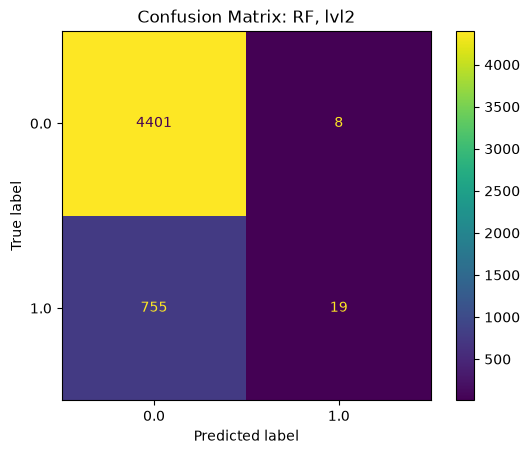

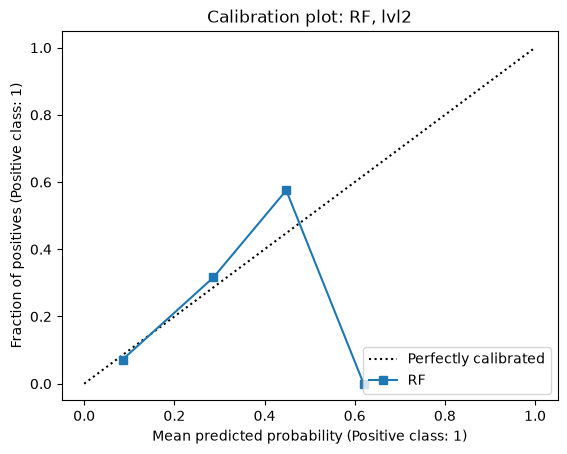

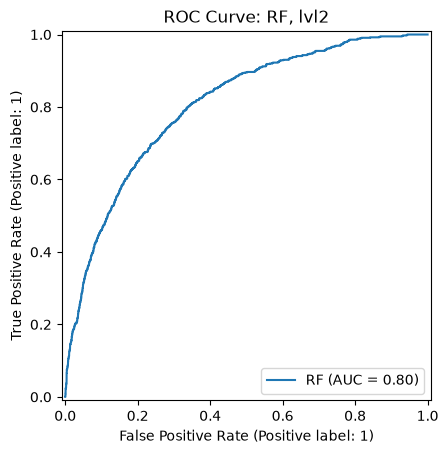

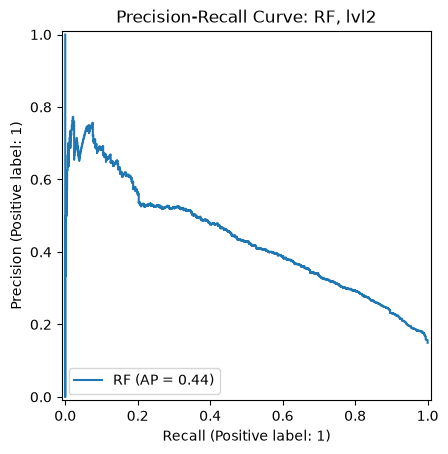

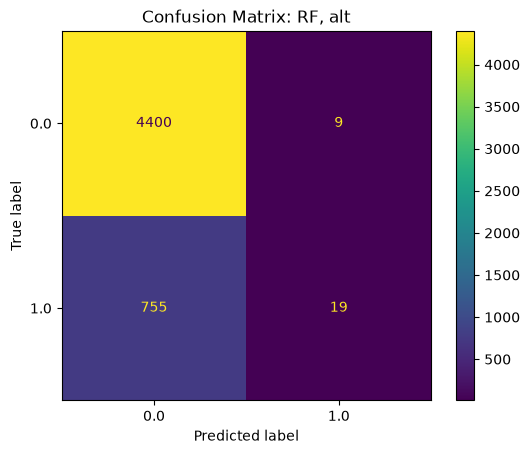

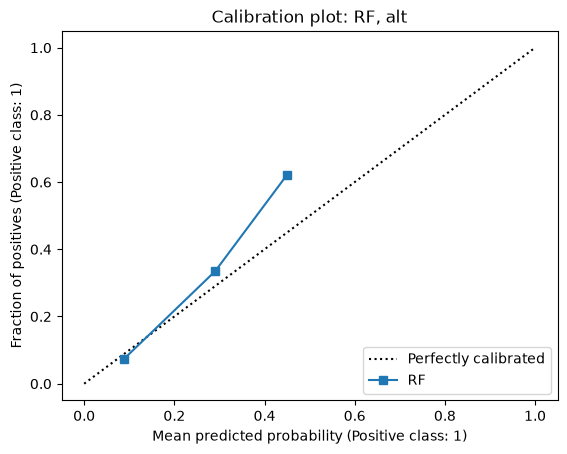

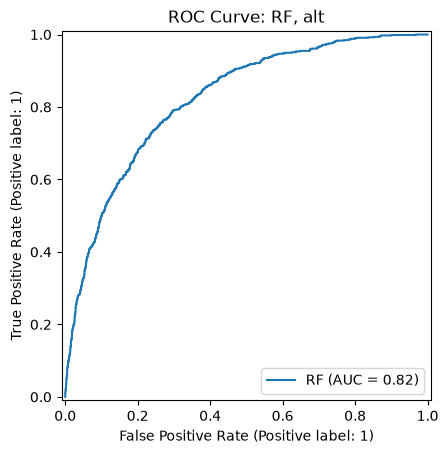

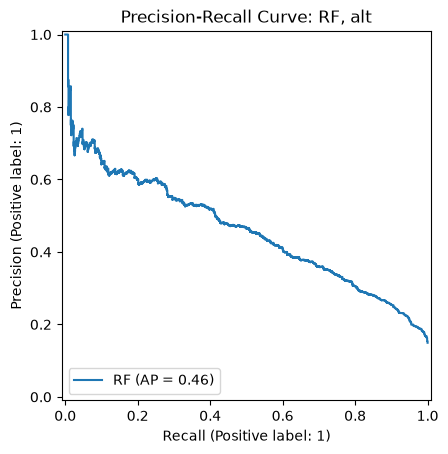

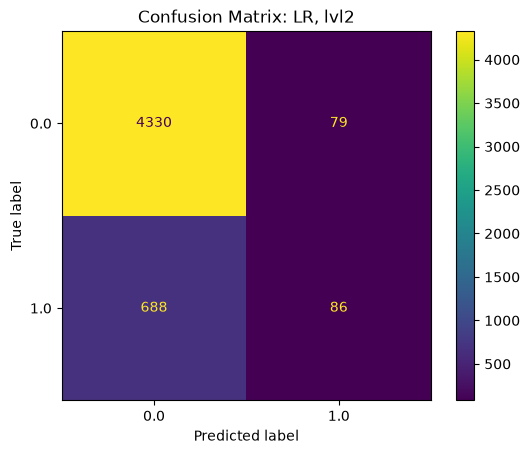

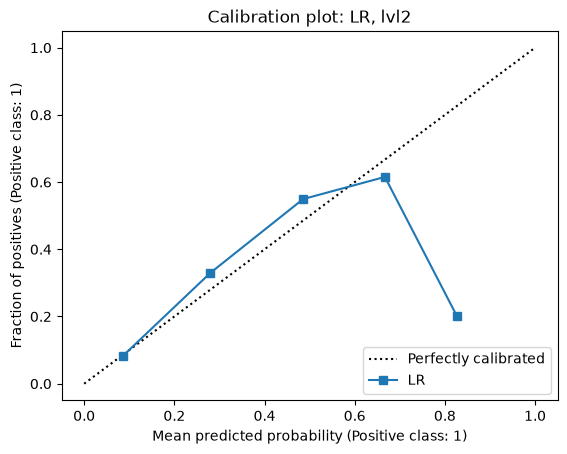

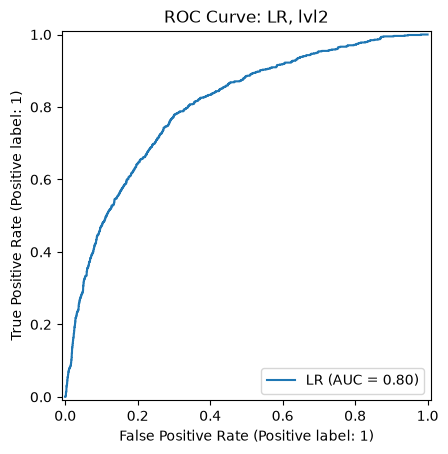

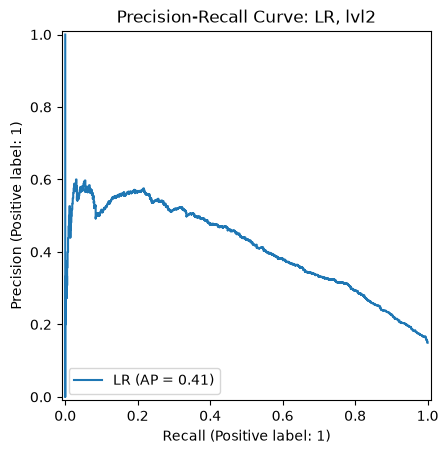

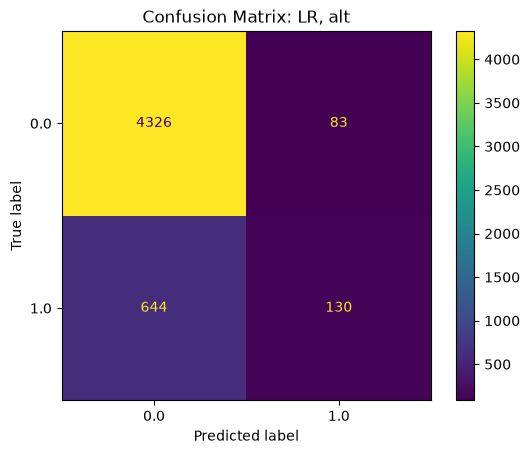

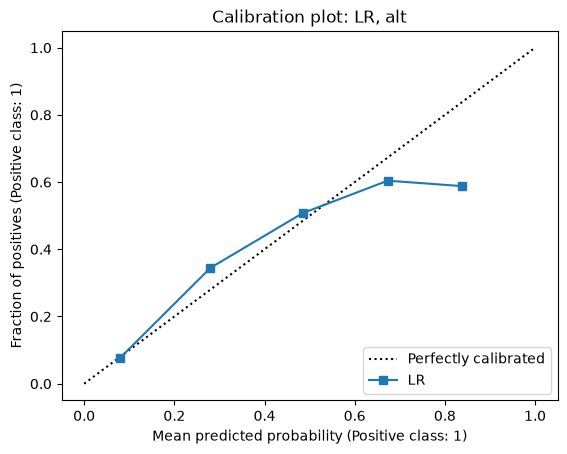

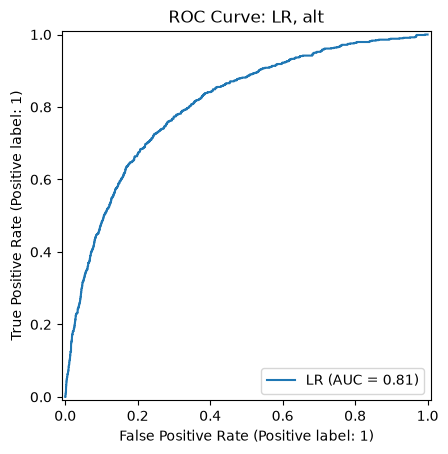

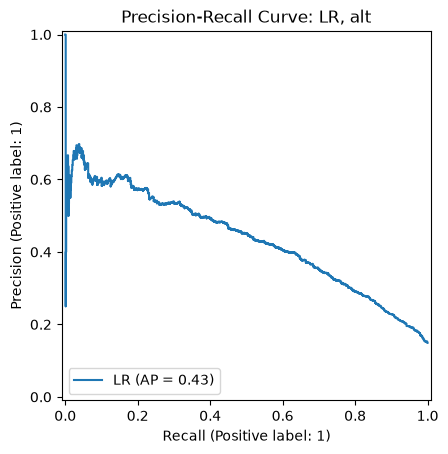

In [ ]:
# confusion matrix and plots for both RF and LR together

#flat_dev = {'lvl2': lvl2_flat_dev, 'alt': alt_flat_dev}
flat_test = {'lvl2': lvl2_flat_test, 'alt': alt_flat_test}

for model_name in ('RF', 'LR'):
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_test['los_7']            # now looking at test
        y_pred = best_M.predict(flat_test[n])  # now looking at test
        y_prob = best_M.predict_proba(flat_test[n])[:, 1]

        label = f'{model_name}, {n}'

        # confusion matrix:
        matrix = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
        matrix.ax_.set_title(f'Confusion Matrix: {label}')
        matrix.figure_.savefig(PLOTS_DIR / f'confusion_matrix_{model_name}_{n}.png')

        # calibration plot
        calib_plot = CalibrationDisplay.from_predictions(y_true, y_prob, name = model_name)
        calib_plot.ax_.set_title(f'Calibration plot: {label}')
        calib_plot.figure_.savefig(PLOTS_DIR / f'calibration_{model_name}_{n}.png')

        # auc-roc
        auc_roc_plot = RocCurveDisplay.from_predictions(y_true, y_prob, name = model_name)
        auc_roc_plot.ax_.set_title(f'ROC Curve: {label}')
        auc_roc_plot.figure_.savefig(PLOTS_DIR / f'auc_roc_{model_name}_{n}.png')

        # au-prc
        au_prc_plot = PrecisionRecallDisplay.from_predictions(y_true, y_prob, name = model_name)
        au_prc_plot.ax_.set_title(f'Precision-Recall Curve: {label}')
        au_prc_plot.figure_.savefig(PLOTS_DIR / f'au_prc_{model_name}_{n}.png')

In [ ]:
# find optimum threshold for sensitivity/specificity based on F1 score: LR

#flat_dev = {'lvl2': lvl2_flat_dev, 'alt': alt_flat_dev}
flat_test = {'lvl2': lvl2_flat_test, 'alt': alt_flat_test}


best_thresholds = {}
for model_name in ('LR', 'RF'):
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_test['los_7']
        y_prob = best_M.predict_proba(flat_test[n])[:, 1]

        precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
        print(precision)
        print(recall)
        print(thresholds)

        f1 = 2 * ((precision * recall) / (precision + recall + 1e-12)) # adding small addition to deal with zeros

        f1 = f1[:-1]  # remove last entry in array 
        f1idx = np.argmax(f1)
        print (f"Threshold for maximum F1 for {model_name}, {n}: {thresholds[f1idx]})")
        best_thresholds[(model_name, n)] = thresholds[f1idx]

[0.14933436 0.14936318 0.14939201 ... 0.         0.         1.        ]
[1. 1. 1. ... 0. 0. 0.]
[0.00310782 0.00665773 0.00668829 ... 0.8229924  0.82864198 0.86596492]
Threshold for maximum F1 for LR, lvl2: 0.21088525815231313)
[0.14933436 0.14936318 0.14939201 ... 0.5        1.         1.        ]
[1.         1.         1.         ... 0.00129199 0.00129199 0.        ]
[3.58310121e-06 4.35680726e-04 7.00839528e-04 ... 8.84838833e-01
 8.87678754e-01 9.01656008e-01]
Threshold for maximum F1 for LR, alt: 0.18519781983698744)
[0.14933436 0.14950744 0.14956522 ... 0.         0.         1.        ]
[1. 1. 1. ... 0. 0. 0.]
[0.00000000e+00 4.38596491e-04 5.84795322e-04 ... 5.70481382e-01
 5.83991856e-01 6.19762361e-01]
Threshold for maximum F1 for RF, lvl2: 0.23253400626633905)
[0.14933436 0.14936318 0.14939201 ... 1.         1.         1.        ]
[1.         1.         1.         ... 0.00258398 0.00129199 0.        ]
[0.00455646 0.00455903 0.00533144 ... 0.56772016 0.57005596 0.57500104]
Thr

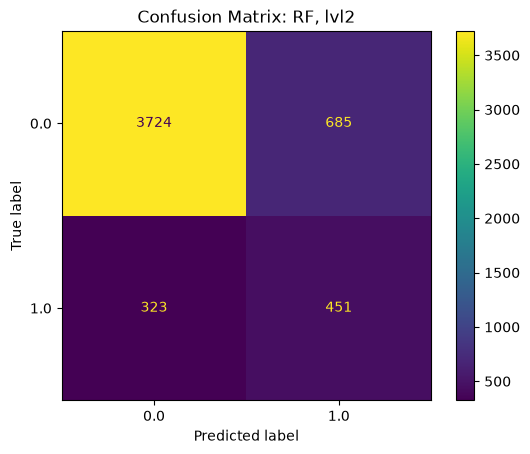

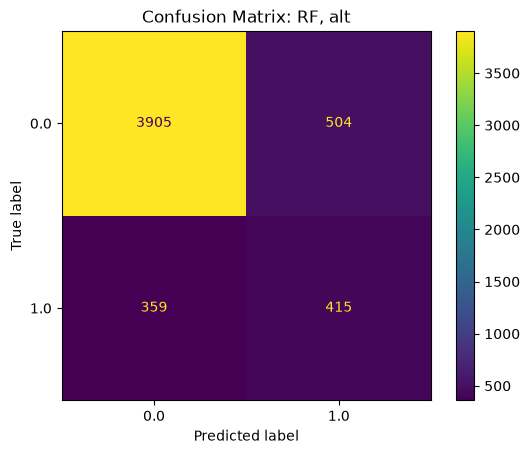

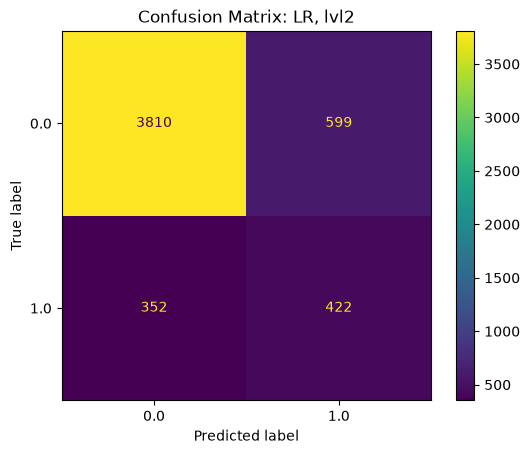

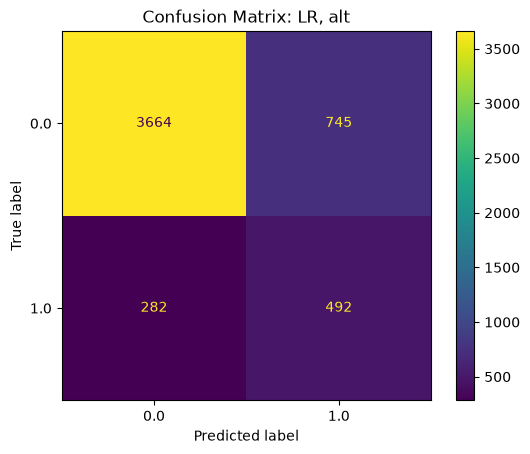

In [ ]:
# Try confusion matrix with these thresholds.

flat_dev = {'lvl2': lvl2_flat_dev, 'alt': alt_flat_dev}
flat_test = {'lvl2': lvl2_flat_test, 'alt': alt_flat_test}


for model_name in ('RF', 'LR'):
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_test['los_7']       
        #y_pred = best_M.predict(lvl2_flat_dev)  
        y_prob = best_M.predict_proba(flat_test[n])[:, 1]

        y_pred = (y_prob >= best_thresholds[(model_name, n)]).astype(float)  # using threshold extracted above

        label = f'{model_name}, {n}'

        # confusion matrix:
        matrix = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
        matrix.ax_.set_title(f'Confusion Matrix: {label}')
        matrix.figure_.savefig(PLOTS_DIR / f'confusion_matrix_{model_name}_{n}.png')

In [ ]:
# get sensitivity, specificity, etc. based on the optimum thresholds

metrics = {}

#flat_dev = {'lvl2': lvl2_flat_dev, 'alt': alt_flat_dev}
flat_test = {'lvl2': lvl2_flat_test, 'alt': alt_flat_test}

for model_name in ('RF', 'LR'):
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_test['los_7']       
        #y_pred = best_M.predict(lvl2_flat_test)  
        y_prob = best_M.predict_proba(flat_test[n])[:, 1]
        y_pred = (y_prob >= best_thresholds[(model_name, n)]).astype(float)  # using threshold extracted above

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        sensitivity = tp / (tp + fn)    # same as recall. proportion of true positives correctly predicted
        specificity = tn / (tn + fp)    # proportion of true negatives correctly predicted
        precision = tp / (tp + fp)      # proportion of predicted positives that were correct
        f1 = 2 * ((precision * sensitivity) / (precision + sensitivity)) 

        metrics[(model_name, n)] = {
            'threshold': best_thresholds[(model_name, n)],
            'sensitivity': sensitivity,
            'specificity': specificity,
            'precision': precision,
            'F1': f1
        }
threshold_metrics = pd.DataFrame(metrics).T
print(threshold_metrics)
threshold_metrics.to_csv(TABLES_DIR / 'threshold_metrics.csv', index=False)



         threshold  sensitivity  specificity  precision        F1
RF lvl2   0.232534     0.582687     0.844636   0.397007  0.472251
   alt    0.253030     0.536176     0.885688   0.451578  0.490254
LR lvl2   0.210885     0.545220     0.864142   0.413320  0.470195
   alt    0.185198     0.635659     0.831027   0.397736  0.489309
